# Quantification

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('../signal.mplstyle')

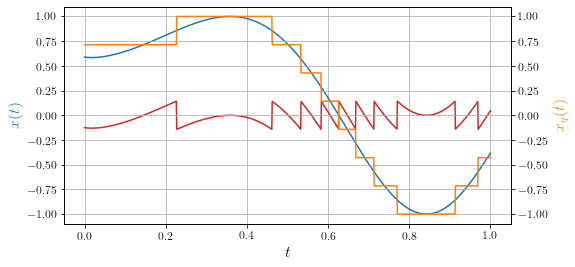

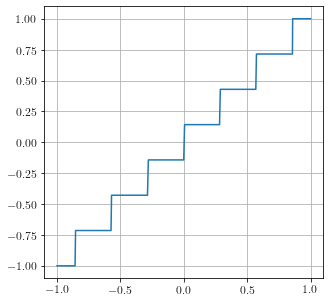

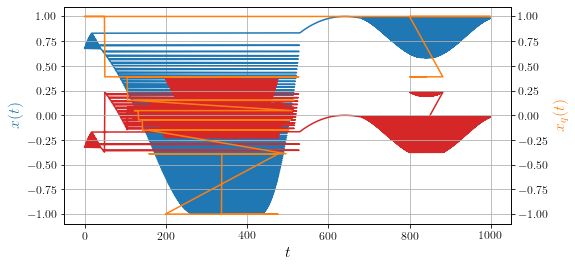

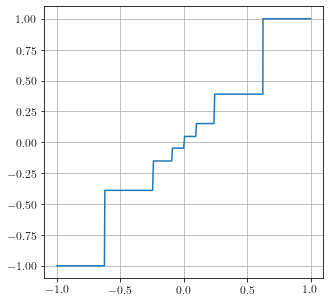

In [2]:
################## QUANTIF

# Quantification uniforme
def uniform_quantization(x, K):#, xmin, xmax):
    # x = np.clip(x, xmin, xmax)
    q = 2/(K-1)#(xmax-xmin)/(K-1)
    xq = q * (np.floor(x/q)+.5)
    levels = -1#np.arange(xmin, xmax, K)
    return xq, levels

# Quantification en loi A
def lawA_quantization(x, K):#, xmin, xmax):
    
    A = 10
    
    Ax = A*np.abs(x)
    den = 1 + np.log(A)
    z = np.sign(x) * np.where( np.abs(x)<1/A, Ax/den, (1+np.log(Ax))/den)
    
    
    # z = np.clip(z, xmin, xmax)
    # q = (xmax-xmin)/(K-1)
    # zq = q * np.floor(z/q+.5)
    zq, _ = uniform_quantization(z, K)#, z.min(), z.max())
    
    num = np.abs(zq)*(1+np.log(A))
    z = np.sign(zq)* np.where( np.abs(zq)<1/(1+np.log(A)),
                              num/A,
                              np.exp(num-1)/A)
    
    xq = z#uniform_quantization(z, K, xmin, xmax)
    
    levels = -1#
    return xq, levels

################## SIGNAL ET SIGNAL CARAC

N = 1000
n = np.linspace(0,1,N)
x = .8 * np.sin(2*np.pi*n**1.5) - n + .5
# x = 1.2 * np.sin(2*np.pi*n**1.5) - n + .4
x = (x-x.min()) / (x.max()-x.min()) * 2 - 1

# y = np.arange(-1.5, 1.5, .01)

########################## AFFICHAGE

K = 8
# xmin, xmax = -1.2, 0.9

for quantif in [uniform_quantization, lawA_quantization]:
    
    xq, _ = quantif(x, K)
    
#     # Tick label
#     qticks = np.arange(xmin, xmax+q, q)
#     qticklabels = (qticks-xmin)/q
#     qticklabels = qticklabels.astype(int)
#     yqticklabel = [f"{i} ({i:0>3b})" for i in qticklabels]
    
    # Signal quantifié
    fig, ax = plt.subplots(figsize=(8,4))
    axq = ax.twinx()
    clr, clrq = "tab:blue", "tab:orange"
    ax.plot(n, x, color=clr)
    ax.set_xlabel("$t$", fontsize=16)
    ax.set_ylabel("$x(t)$", color=clr, fontsize=16)
    # ax.set_yticks(np.arange(-1.5, 1.2, .3))
    ax.grid(axis="x", visible=True)
    ax.grid(axis="y", visible=False)
    axq.plot(n, xq, color=clrq)
    axq.set_ylabel("$x_q(t)$", color=clrq, fontsize=16)
    # axq.set_yticks(qticks)
    # axq.set_yticklabels(yqticklabel)
    # axq.set_ylim(ax.get_ylim())
    # axq.grid(axis="x", visible=False)
    # axq.grid(axis="y", visible=True)
#     # plt.savefig("quantification-signal.svg")
    ax.plot(n, x-xq, color="tab:red")
    # ax.fill_between([0, 1], [-q/2, -q/2], [q/2, q/2],color='tab:red', alpha=0.1)
    plt.show()
#     # plt.savefig("quantification-erreur.svg")

    # Caractéristique
    fig, ax = plt.subplots(figsize=(5,5))
    n = np.argsort(x)
    plt.plot(x[n], xq[n])
#     ax.set_yticks(qticks)
#     ax.set_yticklabels(yqticklabel)
#     ax.set_xlabel("Entrée non quantifiée $x$", fontsize=16)
#     ax.set_ylabel("Sortie quantifiée $x_q$", fontsize=16)
#     ax.set_xticks(np.arange(-1.5, 1.501, .3))
#     ax.set_xlim([-(K/2+1)*q, (K/2+1)*q])
#     ax.set_ylim([-(K/2+1)*q, (K/2+1)*q])
#     # plt.savefig("quantification-caracteristique.svg")
    plt.show()

In [7]:
xq = np.array([7, 4, 9, 3, 4, 1])
n = np.argsort(xq)
print(n)
print(xq[n])

[5 3 1 4 0 2]
[1 3 4 4 7 9]


<function qu at 0x7fa4b6fba820> 8 -1.2 0.9


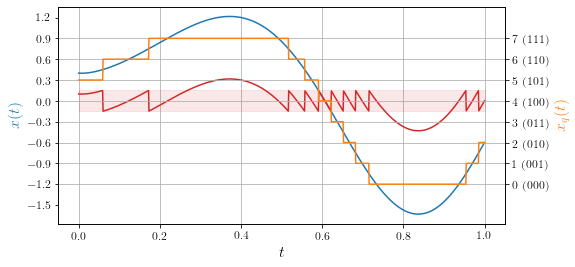

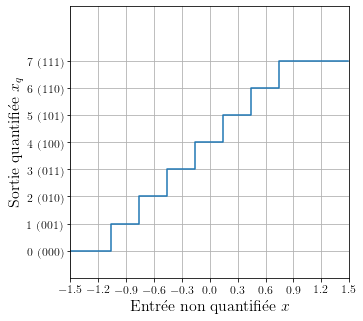

<function qnu at 0x7fa4b7052310> 8 -1.2 0.9


ValueError: x and y must have same first dimension, but have shapes (1000,) and (300,)

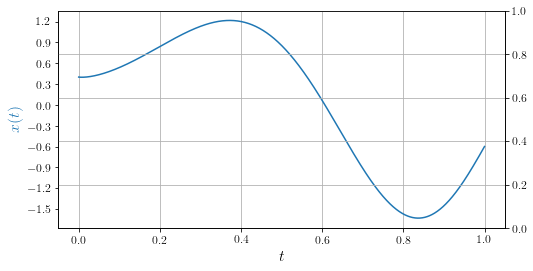

In [14]:
################## SIGNAL ET SIGNAL CARAC

N = 1000
n = np.linspace(0,1,N)
x = 1.2 * np.sin(2*np.pi*n**1.5) - n + .4

y = np.arange(-1.5, 1.5, .01)

################## QUANTIF

K = 8
xmin = -1.2
xmax = 0.9

def qu(x, K, xmin, xmax):
    q = (xmax-xmin)/(K-1)
    x = np.clip(x, xmin, xmax)
    return q * np.floor(x/q+.5), q

def qnu(x, K, xmin, xmax):
    A = 10
    q = (xmax-xmin)/(K-1)
    Ay = A*np.abs(y)
    den = 1+np.log(A)
    z = np.where(np.abs(y)<1/A,
                 np.sign(y) * Ay / den,
                 np.sign(y) * (1+np.log(Ay)) / den)
    yq, q = qu(z, K, xmin, xmax)
    return yq, q

################## AFFICHAGE

for quantif in [qu, qnu]:
    
    print(quantif, K, xmin, xmax)
    
    xq, q = quantif(x, K, xmin, xmax)
    yq, _ = quantif(y, K, xmin, xmax)

    # Tick label
    qticks = np.arange(xmin, xmax+q, q)
    qticklabels = (qticks-xmin)/q
    qticklabels = qticklabels.astype(int)
    yqticklabel = [f"{i} ({i:0>3b})" for i in qticklabels]
    
    # Signal quantifié
    fig, ax = plt.subplots(figsize=(8,4))
    axq = ax.twinx()
    clr, clrq = "tab:blue", "tab:orange"
    ax.plot(n, x, color=clr)
    ax.set_xlabel("$t$", fontsize=16)
    ax.set_ylabel("$x(t)$", color=clr, fontsize=16)
    ax.set_yticks(np.arange(-1.5, 1.2, .3))
    ax.grid(axis="x", visible=True)
    ax.grid(axis="y", visible=False)
    axq.plot(n, xq, color=clrq)
    axq.set_ylabel("$x_q(t)$", color=clrq, fontsize=16)
    axq.set_yticks(qticks)
    axq.set_yticklabels(yqticklabel)
    axq.set_ylim(ax.get_ylim())
    axq.grid(axis="x", visible=False)
    axq.grid(axis="y", visible=True)
    # plt.savefig("quantification-signal.svg")
    ax.plot(n, x-xq, color="tab:red")
    ax.fill_between([0, 1], [-q/2, -q/2], [q/2, q/2],color='tab:red', alpha=0.1)
    plt.show()
    # plt.savefig("quantification-erreur.svg")

    # Caractéristique
    fig, ax = plt.subplots(figsize=(5,5))
    ax.step(y, yq)
    ax.set_yticks(qticks)
    ax.set_yticklabels(yqticklabel)
    ax.set_xlabel("Entrée non quantifiée $x$", fontsize=16)
    ax.set_ylabel("Sortie quantifiée $x_q$", fontsize=16)
    ax.set_xticks(np.arange(-1.5, 1.501, .3))
    ax.set_xlim([-(K/2+1)*q, (K/2+1)*q])
    ax.set_ylim([-(K/2+1)*q, (K/2+1)*q])
    # plt.savefig("quantification-caracteristique.svg")
    plt.show()

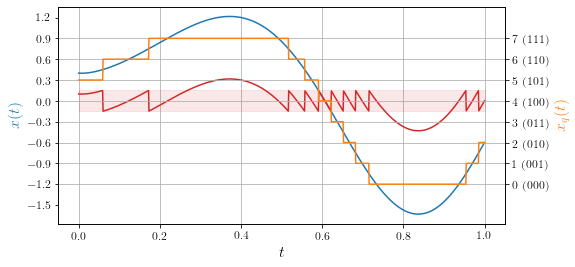

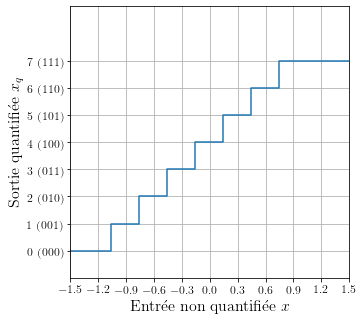

In [30]:
# Signal
N = 1000
n = np.linspace(0,1,N)
x = 1.2 * np.sin(2*np.pi*n**1.5) - n + .4

# Caractéristique de quantification
y = np.arange(-2, 2, .01)

# Quantification uniforme par arrondi
q = .3
K = 8
xmin = -K/2*q
xmax = (K/2-1)*q
qticks = np.arange(xmin, xmax+q, q)
def quantif(x, q, K):
    x = np.clip(x, xmin, xmax)
    return q * np.floor(x/q+.5)
xq = quantif(x, q, K)
yq = quantif(y, q, K)

# Tick label
qticklabels = (qticks-xmin)/q
qticklabels = qticklabels.astype(int)
yqticklabel = [f"{i} ({i:0>3b})" for i in qticklabels]

print()

# Signal quantifié
fig, ax = plt.subplots(figsize=(8,4))
axq = ax.twinx()
clr, clrq = "tab:blue", "tab:orange"
ax.plot(n, x, color=clr)
ax.set_xlabel("$t$", fontsize=16)
ax.set_ylabel("$x(t)$", color=clr, fontsize=16)
ax.set_yticks(np.arange(-1.5, 1.2, .3))
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
axq.plot(n, xq, color=clrq)
axq.set_ylabel("$x_q(t)$", color=clrq, fontsize=16)
axq.set_yticks(qticks)
axq.set_yticklabels(yqticklabel)
axq.set_ylim(ax.get_ylim())
axq.grid(axis="x", visible=False)
axq.grid(axis="y", visible=True)
plt.savefig("quantification-signal.svg")
ax.plot(n, x-xq, color="tab:red")
ax.fill_between([0, 1], [-q/2, -q/2], [q/2, q/2],color='tab:red', alpha=0.1)
plt.savefig("quantification-erreur.svg")

# Caractéristique
fig, ax = plt.subplots(figsize=(5,5))
ax.step(y, yq)
ax.set_yticks(qticks)
ax.set_yticklabels(yqticklabel)
ax.set_xlabel("Entrée non quantifiée $x$", fontsize=16)
ax.set_ylabel("Sortie quantifiée $x_q$", fontsize=16)
ax.set_xticks(np.arange(-1.5, 1.501, .3))
ax.set_xlim([-(K/2+1)*q, (K/2+1)*q])
ax.set_ylim([-(K/2+1)*q, (K/2+1)*q])
plt.savefig("quantification-caracteristique.svg")

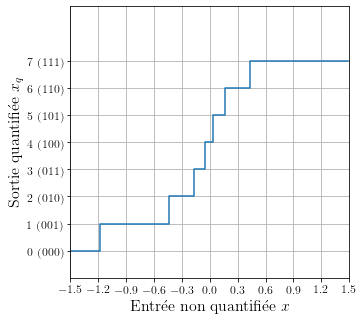

In [31]:
K = 8
A = 10

# Quantification non uniforme (loi A)
y = np.arange(-1.5, 1.5, .01)
xmin = -K/2*q
xmax = (K/2-1)*q
q = (xmax-xmin)/(K-1)
Ay = A*np.abs(y)
den = 1+np.log(A)
z = np.where(np.abs(y)<1/A,
             np.sign(y) * Ay / den,
             np.sign(y) * (1+np.log(Ay)) / den)
yq = quantif(z, q, K)

# Tick label
qticks = np.arange(xmin, xmax+q, q)
qticklabels = (qticks-xmin)/q
qticklabels = qticklabels.astype(int)
yqticklabel = [f"{i} ({i:0>3b})" for i in qticklabels]

# Caractéristique
fig, ax = plt.subplots(figsize=(5,5))
ax.step(y, yq)
ax.set_yticks(qticks)
ax.set_yticklabels(yqticklabel)
ax.set_xlabel("Entrée non quantifiée $x$", fontsize=16)
ax.set_ylabel("Sortie quantifiée $x_q$", fontsize=16)
ax.set_xticks(np.arange(-1.5, 1.501, .3))
ax.set_xlim([-(K/2+1)*q, (K/2+1)*q])
ax.set_ylim([-(K/2+1)*q, (K/2+1)*q])
plt.savefig("quantification-caracteristique-A.svg")

(-1.4999999999999996, 1.4999999999999996)

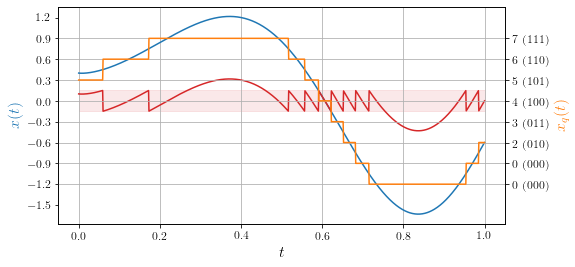

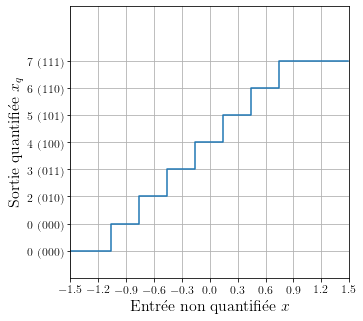

In [10]:
# Signal
N = 1000
n = np.linspace(0,1,N)
x = 1.2 * np.sin(2*np.pi*n**1.5) - n + .4

# Caractéristique de quantification
y = np.arange(-2, 2, .01)

y = np.arange(-1.5, 1.5, .01)

# Quantification
K = 8
A = 10
xmin = -K/2*q
xmax = (K/2-1)*q
q = (xmax-xmin)/(K-1)

Ax = A*np.abs(x)
den = 1+np.log(A)
z = np.where(np.abs(x)<1/A,
             np.sign(x) * Ax / den,
             np.sign(x) * (1+np.log(Ax)) / den)
xq = z


Ay = A*np.abs(y)
den = 1+np.log(A)
z = np.where(np.abs(y)<1/A,
             np.sign(y) * Ay / d
    xmin = -K/2*q
    xmax = (K/2-1)*q
    q = (xmax-xmin)/(K-1)
    Ay = A*np.abs(y)
    den = 1+np.log(A)
    z = np.where(np.abs(y)<1/A,
                 np.sign(y) * Ay / den,
                 np.sign(y) * (1+np.log(Ay)) / den)
    yq = en,
             np.sign(y) * (1+np.log(Ay)) / den)
yq = z

# q = .3
# K = 8
# xmin = -K/2*q
# xmax = (K/2-1)*q
# qticks = np.arange(xmin, xmax+q, q)
# def quantif(x, q, K):
#     x = np.clip(x, xmin, xmax)
#     return q * np.floor(x/q+.5)

xq = quantif(x, q, K)
yq = quantif(y, q, K)

# Tick label
qticklabels = (qticks-xmin)/q
qticklabels = qticklabels.astype(int)
yqticklabel = [f"{i} ({i:0>3b})" for i in qticklabels]

print()

# Signal quantifié
fig, ax = plt.subplots(figsize=(8,4))
axq = ax.twinx()
clr, clrq = "tab:blue", "tab:orange"
ax.plot(n, x, color=clr)
ax.set_xlabel("$t$", fontsize=16)
ax.set_ylabel("$x(t)$", color=clr, fontsize=16)
ax.set_yticks(np.arange(-1.5, 1.2, .3))
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
axq.plot(n, xq, color=clrq)
axq.set_ylabel("$x_q(t)$", color=clrq, fontsize=16)
axq.set_yticks(qticks)
axq.set_yticklabels(yqticklabel)
axq.set_ylim(ax.get_ylim())
axq.grid(axis="x", visible=False)
axq.grid(axis="y", visible=True)
# plt.savefig("quantification-signal.svg")
ax.plot(n, x-xq, color="tab:red")
ax.fill_between([0, 1], [-q/2, -q/2], [q/2, q/2],color='tab:red', alpha=0.1)
# plt.savefig("quantification-erreur.svg")

# Caractéristique
fig, ax = plt.subplots(figsize=(5,5))
ax.step(y, yq)
ax.set_yticks(qticks)
ax.set_yticklabels(yqticklabel)
ax.set_xlabel("Entrée non quantifiée $x$", fontsize=16)
ax.set_ylabel("Sortie quantifiée $x_q$", fontsize=16)
ax.set_xticks(np.arange(-1.5, 1.501, .3))
ax.set_xlim([-(K/2+1)*q, (K/2+1)*q])
ax.set_ylim([-(K/2+1)*q, (K/2+1)*q])
# fig, ax = plt.subplots(figsize=(5,5))
# ax.step(y, yq)
    xmin = -K/2*q
    xmax = (K/2-1)*q
    q = (xmax-xmin)/(K-1)
    Ay = A*np.abs(y)
    den = 1+np.log(A)
    z = np.where(np.abs(y)<1/A,
                 np.sign(y) * Ay / den,
                 np.sign(y) * (1+np.log(Ay)) / den)
    yq = 
# ax.set_yticks(qticks)
# ax.set_yticklabels(yqticklabel)
# ax.set_xlabel("Entrée non quantifiée $x$", fontsize=16)
# ax.set_ylabel("Sortie quantifiée $x_q$", fontsize=16)
# ax.set_xticks(np.arange(-1.5, 1.501, .3))
# ax.set_xlim([-(K/2+1)*q, (K/2+1)*q])
# ax.set_ylim([-(K/2+1)*q, (K/2+1)*q])
# plt.savefig("quantification-caracteristique.svg")

ValueError: x and y must have same first dimension, but have shapes (300,) and (1000,)

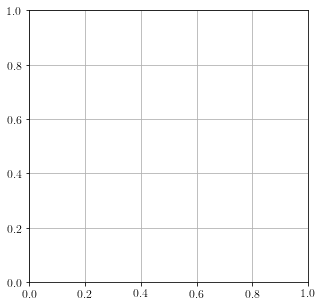